**Simple Classifier**

First, let's bring in all the tools we'll need for this project! We're importing `tensorflow` for building our model, `matplotlib.pyplot` and `seaborn` for making our data look pretty, `numpy` for numerical operations, `os` for interacting with the operating system, and `pandas` for data handling.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import pandas as pd

`tensorflow` and `keras` versions are up to date.

In [ ]:
print(f'Tensorflow Version {tf.__version__}')
print(f'keras Version {tf.keras.__version__}')

Tensorflow Version 2.19.0
keras Version 3.10.0


This is a descriptive title for the section where we'll be building our simple classifier using Keras and the famous MNIST dataset.

Creating a Simple Classifier using Keras on MNIST Data

Here we're loading the MNIST dataset, which is a collection of handwritten digits. It's a classic dataset for getting started with image classification!

In [ ]:
mnist = tf.keras.datasets.mnist


And just like that, we've loaded our data! `X_train_full` and `y_train_full` contain our training images and their labels, and `X_test` and `y_test` are for testing our model later.

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's take a peek at the shape and data type of our training images. This tells us we have 60,000 images, each 28x28 pixels, and the pixel values are `uint8` (unsigned 8-bit integers, usually 0-255).

In [ ]:
print(f'Data tupe of X_train_full :  {X_train_full.dtype},\n shape of x_train_full : {X_train_full.shape}')

Data tupe of X_train_full :  uint8,
 shape of x_train_full : (60000, 28, 28)


In [ ]:
X_test.shape

(10000, 28, 28)

This simply confirms that each image is indeed 28 pixels wide.

In [ ]:
len(X_test[1][0])

28

This is an important step! We're splitting our full training data into actual training data and a separate validation set. This helps us monitor how well our model generalizes to new, unseen data during training. We're also scaling the pixel values from 0-255 down to 0-1, which is a common practice for neural networks and helps with training stability.

-Create a validation data set from the full training data.

-Scale the data between 0 to 1 by dividing it by 255. as its an unsigned data between 0-255 range.

In [ ]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

Don't forget the test set! We need to scale these images the same way we did the training and validation sets so our model sees consistent input.

In [ ]:
X_test = X_test / 255.

Just confirming how many images we have left in our actual training set after creating the validation split. Looks like 55,000 images remain for training.

In [ ]:
len(X_train_full[5000:])

55000

visualize one of our training images! The `cmap='binary'` makes it black and white, and `plt.show()` displays it.

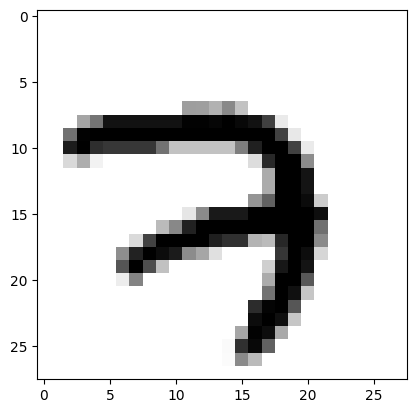

In [ ]:
plt.imshow(X_train[0], cmap = 'binary')
plt.show()

pixel values of the first training image. The `annot=True` parameter shows the actual values, and `cmap='binary'` keeps it in grayscale. This can be really helpful for understanding the raw data your model is seeing.

<Axes: >

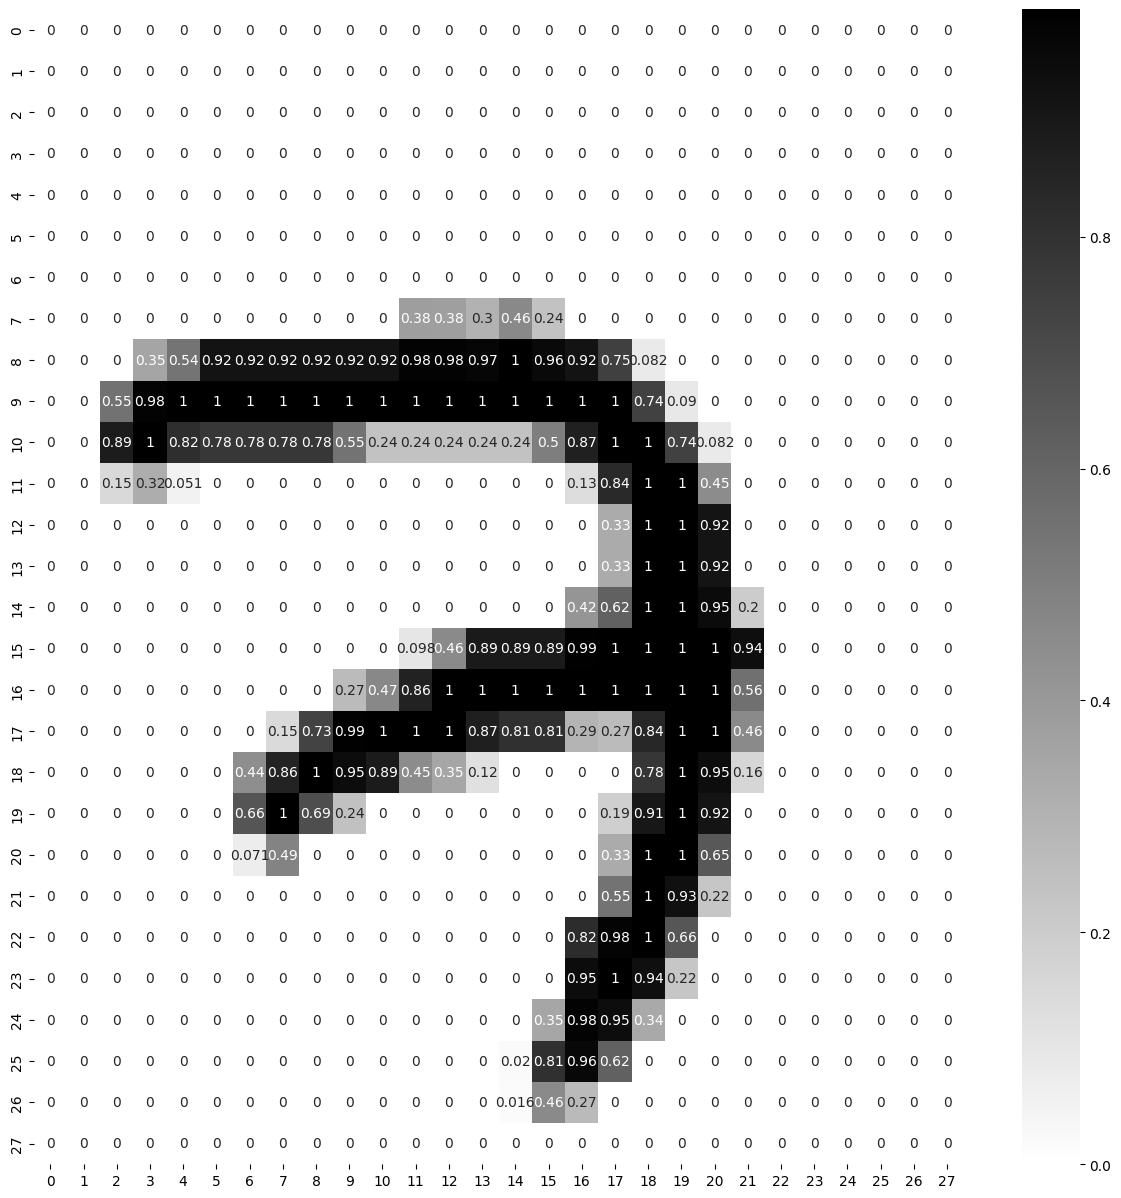

In [ ]:
plt.figure(figsize = (15,15))

sns.heatmap(X_train[0], annot = True, cmap= 'binary')

Architecture Used:

We're defining the layers of our neural network here. It's a `Sequential` model, meaning layers are stacked one after another. We have an `InputLayer` to flatten our 28x28 images into a 784-pixel vector, two `Dense` (fully connected) hidden layers with ReLU activation, and a final `Dense` output layer with `softmax` activation for classification into 10 categories (digits 0-9).

In [ ]:
LAYERS = [tf.keras.layers.Flatten(input_shape= [28,28], name = "InputLayer"),
          tf.keras.layers.Dense(300, activation = 'relu', name = "HiddenLayer1"),
          tf.keras.layers.Dense(100, activation = 'relu',name = 'HiddenLayer2'),
          tf.keras.layers.Dense(10,activation = 'softmax', name = 'OutputLayer')]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Now we're actually creating the `Sequential` model using the layers we defined. `model_clf` is our classifier!

In [ ]:
model_clf = tf.keras.models.Sequential(LAYERS)

This command simply lists the layers within our `model_clf`, confirming that they've been added correctly.

In [ ]:
model_clf.layers

[<Flatten name=InputLayer, built=True>,
 <Dense name=HiddenLayer1, built=True>,
 <Dense name=HiddenLayer2, built=True>,
 <Dense name=OutputLayer, built=True>]

The `summary()` method is super useful! It gives us a quick overview of our model's architecture, including the output shape of each layer and the number of trainable parameters. This helps us understand the complexity of our model.

In [ ]:
model_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer1 (Dense)            │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ HiddenLayer2 (Dense)            │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutputLayer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

We're specifically grabbing the first hidden layer (index 1) and printing its name. This is a way to inspect individual parts of your model.

In [ ]:
hidden1 = model_clf.layers[1]
hidden1.name

'HiddenLayer1'

Each `Dense` layer has weights and biases. This tells us the number of bias terms in `HiddenLayer1`, which should match the number of neurons in that layer (300).

In [ ]:
len(hidden1.get_weights()[1])

300

Here we're retrieving the weights and biases for the first hidden layer. The weights define the connections between neurons, and the biases add an offset.

In [ ]:
hidden1.get_weights()

[array([[ 0.01702017,  0.03610414,  0.05174516, ...,  0.00874403,
         -0.0212473 , -0.05249236],
        [ 0.05036371, -0.0352876 ,  0.00962658, ...,  0.01711912,
          0.01541035, -0.06107794],
        [ 0.03433666, -0.0482561 , -0.01210128, ...,  0.0450203 ,
          0.00990997,  0.04119454],
        ...,
        [-0.06036676, -0.02945435, -0.01673451, ...,  0.04321928,
          0.02732477,  0.00316938],
        [-0.00190306, -0.01217728, -0.01345674, ...,  0.05780378,
          0.03562896,  0.03777835],
        [ 0.05018064, -0.03255393,  0.02509697, ..., -0.02860523,
          0.0170635 , -0.05554873]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

This prints the shape of the `weights` matrix (784 inputs to 300 neurons) and then displays the actual weight values. It's a lot of numbers, but it shows how connected each input pixel is to each neuron in the hidden layer.

In [ ]:
weights, biases = hidden1.get_weights()

In [ ]:
print('shape\n', weights.shape, '\n')
weights

shape
 (784, 300) 



array([[ 0.01702017,  0.03610414,  0.05174516, ...,  0.00874403,
        -0.0212473 , -0.05249236],
       [ 0.05036371, -0.0352876 ,  0.00962658, ...,  0.01711912,
         0.01541035, -0.06107794],
       [ 0.03433666, -0.0482561 , -0.01210128, ...,  0.0450203 ,
         0.00990997,  0.04119454],
       ...,
       [-0.06036676, -0.02945435, -0.01673451, ...,  0.04321928,
         0.02732477,  0.00316938],
       [-0.00190306, -0.01217728, -0.01345674, ...,  0.05780378,
         0.03562896,  0.03777835],
       [ 0.05018064, -0.03255393,  0.02509697, ..., -0.02860523,
         0.0170635 , -0.05554873]], dtype=float32)

And here's the shape of the `biases` vector for the first hidden layer (300 biases, one for each neuron).

In [ ]:
print('Shape\n ', biases.shape)

Shape
  (300,)


We're importing `SparseCategoricalCrossentropy` which is a common loss function for classification problems where the labels are integers (like our digit labels 0-9). The `loss` object is then initialized.

In [ ]:
from keras.losses import SparseCategoricalCrossentropy

loss = SparseCategoricalCrossentropy()

This is where we compile our model! We're telling it what loss function to use (`SparseCategoricalCrossentropy` for our integer labels), which optimizer to use (`SGD` - Stochastic Gradient Descent), and what metrics to track during training (`accuracy`).

In [ ]:
LOSS_FUNCTION = 'Sparse_Categorical_Crossentropy'
OPTIMIZER = 'SGD'
METRICS = ['accuracy']

model_clf.compile(loss = SparseCategoricalCrossentropy,
                  optimizer = OPTIMIZER,
                  metrics = METRICS)

Now for the actual training! We set the number of `EPOCHS` (how many times the model sees the entire training data) and specify our `VALIDATION_SET`. The `model_clf.fit()` method kicks off the training process, and we're also using a `batch_size` of 32, meaning the model updates its weights after processing 32 samples at a time. The `history` object will store all the training metrics.

In [ ]:
EPOCHS = 30
VALIDATION_SET = (X_valid, y_valid)

history = model_clf.fit(X_train, y_train, epochs = EPOCHS,
                        validation_data = VALIDATION_SET, batch_size =32)

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7319 - loss: 1.0249 - val_accuracy: 0.9188 - val_loss: 0.3098
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9139 - loss: 0.3026 - val_accuracy: 0.9364 - val_loss: 0.2378
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9306 - loss: 0.2455 - val_accuracy: 0.9458 - val_loss: 0.2009
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9406 - loss: 0.2031 - val_accuracy: 0.9504 - val_loss: 0.1770
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9493 - loss: 0.1795 - val_accuracy: 0.9556 - val_loss: 0.1578
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9553 - loss: 0.1581 - val_accuracy: 0.9608 - val_loss: 0.1454
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9610 - loss: 0.1378 - val_accuracy: 0.9648 - val_loss: 0.1344
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9638 - loss: 0.1278 - 

This just shows us the parameters used during the training process, confirming the number of epochs and steps per epoch.

In [ ]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

We're converting the `history` object into a pandas DataFrame. This makes it really easy to inspect the training metrics (like accuracy and loss) over each epoch.

In [ ]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.844273,0.607266,0.9188,0.309817
1,0.918145,0.286166,0.9364,0.237823
2,0.933400,0.233647,0.9458,0.200891
3,0.942491,0.199011,0.9504,0.176969
4,0.950273,0.174437,0.9556,0.157750
5,0.956055,0.154798,0.9608,0.145368
6,0.960000,0.139023,0.9648,0.134399
7,0.964164,0.126103,0.9654,0.122519
8,0.967582,0.115096,0.9682,0.115434
9,0.970236,0.105562,0.9698,0.107450


This code generates a plot of our training and validation metrics (accuracy and loss) over the epochs. It's a great way to visualize how well our model is learning and if it's overfitting or underfitting.

<Axes: >

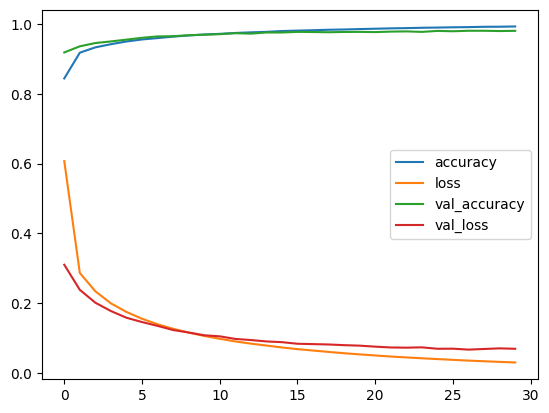

In [ ]:
pd.DataFrame(history.history).plot()

After training, we evaluate our model on the completely unseen test set. This gives us a final, unbiased measure of its performance. The output shows the test loss and test accuracy.

In [ ]:
model_clf.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9731 - loss: 0.0864


[0.07521313428878784, 0.9763000011444092]

We're taking the first three images from our `X_test` set to see how our trained model predicts on a few individual examples.

In [ ]:
x_new = X_test[:3]

And these are the actual labels for those first three test images, so we can compare them to our model's predictions.

In [ ]:
actual = y_test[:3]
actual

array([7, 2, 1], dtype=uint8)

Here's the magic! We're using our trained `model_clf` to predict the probabilities for each digit (0-9) for our `x_new` samples. `round(3)` just makes the output a bit cleaner to read.

In [ ]:
y_prob = model_clf.predict(x_new)
y_prob.round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


array([[0.   , 0.   , 0.001, 0.   , 0.   , 0.   , 0.   , 0.999, 0.   ,
        0.   ],
       [0.   , 0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 0.996, 0.   , 0.   , 0.   , 0.   , 0.001, 0.001, 0.001,
        0.   ]], dtype=float32)

This displays the raw probability outputs from our model for the three test images. Each row sums to 1, representing the model's confidence for each digit.

In [ ]:
y_prob

array([[4.9074797e-06, 8.8350924e-07, 5.7966111e-04, 2.8997628e-04,
        3.2202345e-09, 2.3194891e-06, 1.1120807e-10, 9.9902618e-01,
        3.9581901e-06, 9.2137168e-05],
       [6.8256662e-07, 1.4088751e-04, 9.9979126e-01, 4.6534617e-05,
        1.3907070e-11, 7.6971128e-07, 6.0273042e-06, 9.4693021e-12,
        1.3876827e-05, 6.7060973e-13],
       [2.1685788e-05, 9.9648899e-01, 4.3045281e-04, 7.3578442e-05,
        2.4144520e-04, 8.1219208e-05, 5.2049087e-04, 7.1739574e-04,
        1.4028230e-03, 2.1688787e-05]], dtype=float32)

To get the actual predicted digit, we take the `argmax` (the index of the highest probability) along the last axis of our `y_prob` array. This gives us the model's final classification.

In [ ]:
y_pred = np.argmax(y_prob, axis = -1)

And here are our model's predictions for the three images.

In [ ]:
y_pred

array([7, 2, 1])

Just confirming the actual labels one more time for easy comparison.

In [ ]:
actual

array([7, 2, 1], dtype=uint8)

There was a small typo in the previous cell. This cell corrects it by using the correct variable name `actual` to check its type, which is `numpy.uint8`.

In [ ]:
type(actual_data

numpy.uint8

This is a really nice visualization! We're looping through our `x_new` images, their predicted labels, and their actual labels. For each image, we display it and put a title showing what the model predicted versus what the image actually is. It's a great way to visually confirm our model's performance!

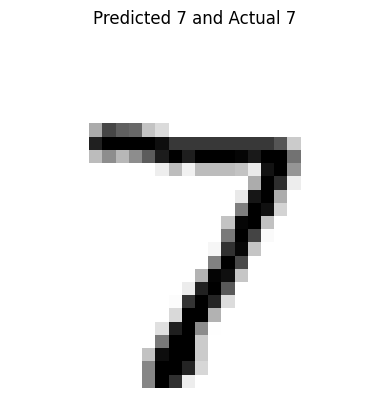

##################################################


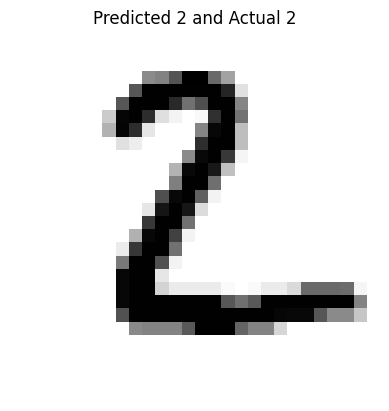

##################################################


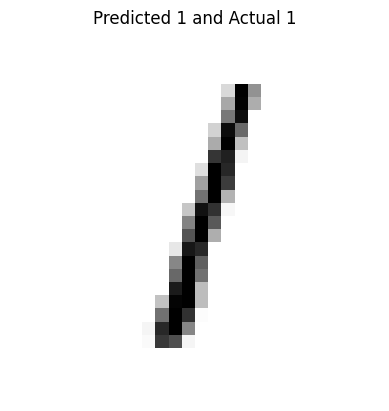

##################################################


In [ ]:
for data, pred, actual_data in zip(x_new, y_pred, actual):
  plt.imshow(data, cmap = 'binary')
  plt.title(f"Predicted {pred} and Actual {actual_data}")
  plt.axis('off')
  plt.show()
  print("#"*50)